# 03 — Validación en vivo contra `rcssserver`

Conecta el cliente Python (`src/client.py`, jugador) y el entrenador (`src/trainer.py`, coach offline) al
contenedor `rcssserver` con la configuración de `docker/docker-compose.yml`
(`coach=true`, `coach_w_referee=false`, `auto_mode=false`).

1. **Chequeo de conexión** (`src/live_check.py`): handshake, reloj, reset, signo del giro, dash vs. modelo.
2. **Estabilidad de largo plazo** (500 episodios consecutivos del controlador heurístico): desconexiones,
   comandos perdidos, cambios de modo de juego, errores de reset.
3. **Secuencias fijas**: física del simulador vs. servidor (dash recto, giro en reposo, giro en movimiento).
4. **Simulador vs. servidor**: la misma política sobre los **mismos inicios** en ambos entornos.
5. **Política aprendida en vivo** (Q-Learning, ε decreciente): tasa de captura frente al criterio de la tarea
   y trayectorias 2D medidas con la verdad de terreno del entrenador.
6. **Aprendizaje visto en el servidor**: políticas guardadas durante el entrenamiento, ejecutadas en vivo.

El paso 1 se ejecuta siempre (≈ 10 s, requiere el servidor). Las evaluaciones largas (≈ 30 y 12 min) se cargan
de `notebooks/artifacts/`; para repetirlas, poner `RUN_LIVE_EVAL = True`.

In [1]:
import json, os, subprocess
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

os.chdir("/workspace") if os.path.isdir("/workspace/src") else None
from src import plots

RUN_LIVE_EVAL = False
ART = "notebooks/artifacts"
GREEDY_EVAL = f"{ART}/live_eval_greedy_500.json"
LEARNED_RUN = open(f"{ART}/live_policy_run.txt").read().strip()   # run dir of the evaluated Q-table
LEARNED_EVAL = f"{ART}/live_eval_{os.path.basename(LEARNED_RUN)}_200.json"
if RUN_LIVE_EVAL:
    subprocess.run(["python", "-m", "src.live_eval", "--policy", "greedy", "--episodes", "500",
                    "--out", GREEDY_EVAL], check=True)
    subprocess.run(["python", "-m", "src.live_eval", "--policy", LEARNED_RUN, "--episodes", "200",
                    "--out", LEARNED_EVAL], check=True)

## 1. Chequeo de conexión con el servidor

In [2]:
out = subprocess.run(["python", "-m", "src.live_check"], capture_output=True, text=True, timeout=120)
print(out.stdout[-3000:] or out.stderr[-3000:])

[PASS] handshakes — side=l unum=7 player_types=18
       params snapshot -> notebooks/artifacts/server_params.json
[PASS] clock advances 1 per cycle — deltas=[1]
       see messages: 20 in 30 cycles, with ball: 0
[PASS] reset matches request — player=(-10.00,0.00) body=0.0 speed=0.000 d=5.00
[PASS] neck zeroed — head_angle=0.0
[PASS] TURN +35 reduces |bearing| of a ball at +20 — theta 20.0 -> -14.0
[PASS] dash displacement matches model (noise tolerance 0.15 m) — measured/model: 0.60/0.60, 0.86/0.84, 1.00/0.94, 0.97/0.97, 1.01/0.99, 1.02/1.00, 1.04/1.00, 1.02/1.00, 0.95/1.00, 1.03/1.00
ALL PASS



## 2. Estabilidad de largo plazo

500 episodios consecutivos con el controlador heurístico en una sola sesión (`play_on` permanente, reset por
entrenador en cada episodio). *Sighting tardío*: `see(t)` que llega después del plazo de decisión de 60 ms y
se usa en el ciclo siguiente (el estimador lo propaga); *obsoleto*: más antiguo que eso (descartado).

In [3]:
greedy = json.load(open(GREEDY_EVAL))
learned = json.load(open(LEARNED_EVAL))
st = greedy["summary"]["stats"]
errors = [e for e in greedy["live"] if "error" in e]
rows = [("episodios completados", f"{greedy['summary']['live']['n']} / {greedy['episodes_requested']}"),
        ("ciclos de servidor", st["cycles"]), ("comandos no ejecutados en su ciclo", st["missed_commands"]),
        ("errores de reset / timeouts", len(errors)),
        ("cambios de modo de juego inesperados", len(greedy["mode_changes"])),
        ("errores/advertencias del servidor", len(greedy["summary"]["server_errors"])),
        ("see tardíos usados", f"{st['late_see']} ({st['late_see'] / st['cycles']:.0%} de los ciclos)"),
        ("see obsoletos descartados", st["stale_see"]),
        ("duración", f"{greedy['started']} → {greedy['finished']}")]
display(Markdown("| métrica | valor |\n|---|---|\n" + "\n".join(f"| {a} | {b} |" for a, b in rows)))

| métrica | valor |
|---|---|
| episodios completados | 500 / 500 |
| ciclos de servidor | 15588 |
| comandos no ejecutados en su ciclo | 0 |
| errores de reset / timeouts | 0 |
| cambios de modo de juego inesperados | 0 |
| errores/advertencias del servidor | 0 |
| see tardíos usados | 5044 (32% de los ciclos) |
| see obsoletos descartados | 0 |
| duración | 2026-09-25 04:35:39 → 2026-09-25 05:03:20 |

## 3. Secuencias fijas de acciones: modelo del simulador vs. servidor

Desde el mismo inicio, cada secuencia se ejecuta 5 veces en el servidor y se compara con la predicción del
simulador **sin ruido** (sesgo del modelo) y con la dispersión propia del servidor (ruido). Posiciones y rumbos
provienen de la verdad de terreno del entrenador (que reporta rumbos redondeados a 1°). *Giro en reposo* se
muestra con 30 repeticiones (180 giros): con solo 5 aparecía un sesgo aparente de +1°/giro que resultó ser
variación muestral.

In [4]:
from src.sim_vs_live import summarize, circular_mean_deg
seq = json.load(open(f"{ART}/sim_vs_live_sequences.json"))
rest30 = json.load(open(f"{ART}/sim_vs_live_turn_at_rest_30.json"))["sequences"]["turn_at_rest"]
names = {"dash100_straight": "DASH 100 ×15 en línea recta", "turn_at_rest": "TURN +35 ×6 en reposo",
         "turn_while_moving": "DASH 100 ×6, TURN +35 ×4, DASH 100 ×4", "dash50_then_turn_neg": "DASH 50 ×6, TURN −35 ×3, DASH 50 ×3"}
lines = ["| secuencia | repeticiones | sesgo máx. de posición [m] | dispersión final en vivo [m] | sesgo máx. de rumbo [°] | dispersión final de rumbo [°] |",
         "|---|---|---|---|---|---|"]
entries = [(k, e) for k, e in seq["sequences"].items() if k != "turn_at_rest"] + [("turn_at_rest", rest30)]
for key, e in entries:
    s = summarize(e)
    lines.append(f"| {names[key]} | {len(e['live'])} | {s['max_position_bias_m']:.3f} | {s['live_final_spread_m']:.3f} | "
                 f"{s['max_heading_bias_deg']:.2f} | {abs(s['live_final_heading_spread_deg']):.2f} |")
display(Markdown("\n".join(lines)))

lb = np.array([[p["body"] for p in r] for r in rest30["live"]])
turns = ((np.diff(lb, axis=1) + 180) % 360 - 180).ravel()
print(f"giro en reposo (n = {turns.size}): media {turns.mean():.2f}° ± {turns.std() / np.sqrt(turns.size):.2f} (EE), "
      f"desv. est. {turns.std():.2f}° — modelo: 35.00°, desv. est. {3.5 / np.sqrt(3):.2f}° (ruido uniforme ±10 %)")

e = seq["sequences"]["turn_while_moving"]
lb = np.array([[p["body"] for p in r] for r in e["live"]]); eb = np.array([p["body"] for p in e["sim_exact"]])
dl = (np.diff(lb, axis=1) + 180) % 360 - 180; de = (np.diff(eb) + 180) % 360 - 180
k = np.flatnonzero(de)
display(Markdown("**Giro en movimiento** (35 / (1 + 5·v)), por paso de giro: " + ", ".join(
    f"modelo {de[i]:.1f}° / servidor {dl[:, i].mean():.1f}°" for i in k)))

| secuencia | repeticiones | sesgo máx. de posición [m] | dispersión final en vivo [m] | sesgo máx. de rumbo [°] | dispersión final de rumbo [°] |
|---|---|---|---|---|---|
| DASH 100 ×15 en línea recta | 5 | 0.055 | 0.210 | 0.00 | 0.00 |
| DASH 100 ×6, TURN +35 ×4, DASH 100 ×4 | 5 | 0.162 | 0.307 | 0.84 | 2.58 |
| DASH 50 ×6, TURN −35 ×3, DASH 50 ×3 | 5 | 0.053 | 0.071 | 0.63 | 1.10 |
| TURN +35 ×6 en reposo | 30 | 0.000 | 0.000 | 0.80 | 4.93 |

giro en reposo (n = 180): media 35.03° ± 0.16 (EE), desv. est. 2.13° — modelo: 35.00°, desv. est. 2.02° (ruido uniforme ±10 %)


**Giro en movimiento** (35 / (1 + 5·v)), por paso de giro: modelo 11.7° / servidor 12.2°, modelo 19.5° / servidor 19.8°, modelo 26.5° / servidor 26.0°, modelo 31.0° / servidor 31.6°

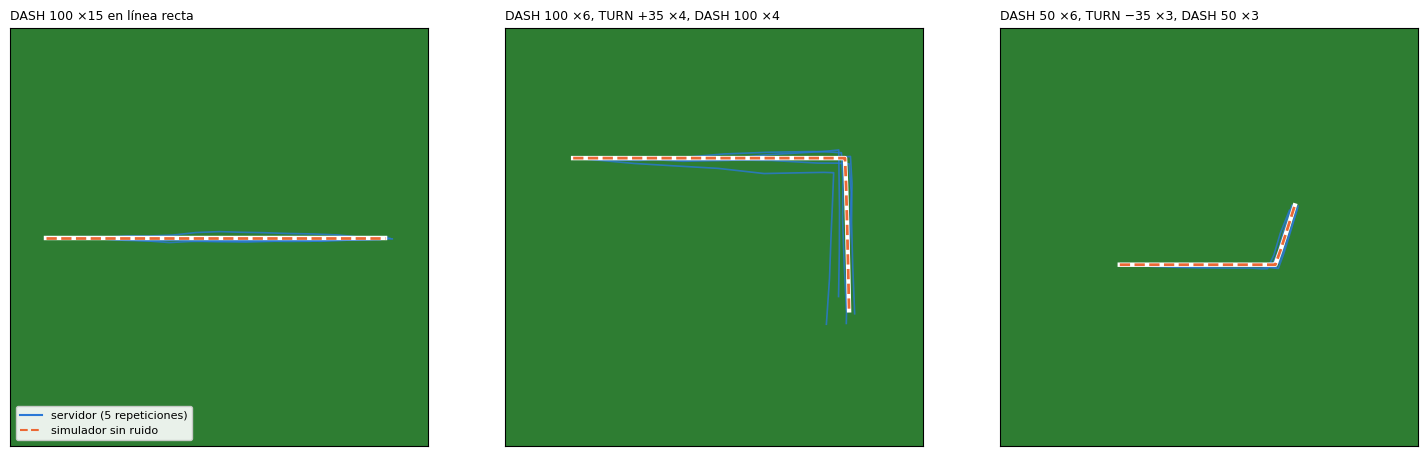

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, key in zip(axes, ["dash100_straight", "turn_while_moving", "dash50_then_turn_neg"]):
    e = seq["sequences"][key]
    plots.draw_pitch(ax)
    for r in e["live"]:
        ax.plot([p["x"] for p in r], [p["y"] for p in r], color=plots.SERIES[0], linewidth=1.2, alpha=0.8)
    ex = [p["x"] for p in e["sim_exact"]]; ey = [p["y"] for p in e["sim_exact"]]
    ax.plot(ex, ey, color="white", linewidth=3.2); ax.plot(ex, ey, color=plots.SERIES[1], linewidth=2, linestyle="--")
    xs = [p["x"] for r in e["live"] for p in r] + ex; ys = [p["y"] for r in e["live"] for p in r] + ey
    cx, cy, half = (min(xs) + max(xs)) / 2, (min(ys) + max(ys)) / 2, max(4.0, (max(xs) - min(xs)) / 2 + 1.5)
    ax.set_xlim(cx - half, cx + half); ax.set_ylim(cy + half, cy - half)
    ax.set_title(names[key], fontsize=9, loc="left")
axes[0].plot([], [], color=plots.SERIES[0], label="servidor (5 repeticiones)")
axes[0].plot([], [], color=plots.SERIES[1], linestyle="--", label="simulador sin ruido")
axes[0].legend(fontsize=8, loc="lower left", framealpha=0.9)
fig.tight_layout(); fig.savefig(f"{ART}/fig_sequences_sim_vs_live.png", dpi=200)

## 4. Simulador vs. servidor sobre los mismos inicios

Para cada política, los mismos inicios (`sampler.evaluation_starts`, semilla 2026) se ejecutan en el
simulador y en el servidor. Error estándar binomial entre paréntesis. La tabla de concordancia compara
episodio a episodio (captura en < 40 pasos).

In [6]:
def rate(eps, budget):
    ok = [e for e in eps if "error" not in e]
    p = np.mean([(e["capture_step"] or 10**6) <= budget for e in ok])
    return p, np.sqrt(p * (1 - p) / len(ok)), len(ok)

lines = ["| política | entorno | n | captura <40 | captura ≤40 | pasos medios | G₀ medio |", "|---|---|---|---|---|---|---|"]
for name, res in (("controlador heurístico", greedy), ("Q-Learning (ε decreciente)", learned)):
    for env in ("sim", "live"):
        eps = [e for e in res[env] if "error" not in e]
        p, se, n = rate(eps, 39); q, _, _ = rate(eps, 40)
        lines.append(f"| {name} | {'simulador' if env == 'sim' else 'servidor'} | {n} | {p:.3f} (±{se:.3f}) | {q:.3f} | "
                     f"{np.mean([e['steps'] for e in eps]):.1f} | {np.mean([e['return'] for e in eps]):.1f} |")
display(Markdown("\n".join(lines)))

for name, res in (("controlador heurístico", greedy), ("Q-Learning", learned)):
    live = {e["index"]: (e["capture_step"] or 10**6) <= 39 for e in res["live"] if "error" not in e}
    sim = {e["index"]: (e["capture_step"] or 10**6) <= 39 for e in res["sim"]}
    both = [i for i in live if i in sim]
    m = {(a, b): sum(1 for i in both if (sim[i], live[i]) == (a, b)) for a in (True, False) for b in (True, False)}
    display(Markdown(f"**{name}** — concordancia por episodio (n = {len(both)}): ambos capturan {m[(True, True)]}, "
                     f"solo simulador {m[(True, False)]}, solo servidor {m[(False, True)]}, ninguno {m[(False, False)]}"))

| política | entorno | n | captura <40 | captura ≤40 | pasos medios | G₀ medio |
|---|---|---|---|---|---|---|
| controlador heurístico | simulador | 500 | 0.676 (±0.021) | 0.700 | 30.0 | 85.1 |
| controlador heurístico | servidor | 500 | 0.672 (±0.021) | 0.698 | 30.2 | 84.8 |
| Q-Learning (ε decreciente) | simulador | 200 | 0.715 (±0.032) | 0.745 | 30.2 | 90.3 |
| Q-Learning (ε decreciente) | servidor | 200 | 0.735 (±0.031) | 0.765 | 30.1 | 92.2 |

**controlador heurístico** — concordancia por episodio (n = 500): ambos capturan 309, solo simulador 29, solo servidor 27, ninguno 135

**Q-Learning** — concordancia por episodio (n = 200): ambos capturan 137, solo simulador 6, solo servidor 10, ninguno 47

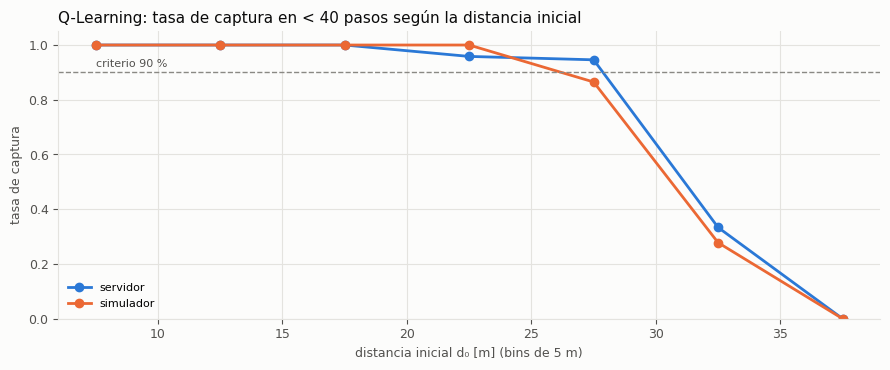

In [7]:
edges = [5, 10, 15, 20, 25, 30, 35, 40]
fig, ax = plt.subplots(figsize=(9, 3.8))
for i, (env, label) in enumerate((("live", "servidor"), ("sim", "simulador"))):
    eps = [e for e in learned[env] if "error" not in e]
    d0 = np.array([e["start"]["distance"] for e in eps])
    ok = np.array([(e["capture_step"] or 10**6) <= 39 for e in eps])
    centers, rates = [], []
    for a, b in zip(edges, edges[1:]):
        m = (d0 >= a) & (d0 < b)
        if m.any():
            centers.append((a + b) / 2); rates.append(ok[m].mean())
    ax.plot(centers, rates, "-o", color=plots.SERIES[i], linewidth=2, markersize=6, label=label)
ax.axhline(0.9, color=plots.REF, linestyle="--", linewidth=1)
ax.annotate("criterio 90 %", ((edges[0] + edges[1]) / 2, 0.9), xytext=(0, 4), textcoords="offset points", fontsize=8, color=plots.TEXT_2)
ax.set_ylim(0, 1.05)
plots.style(ax, "Q-Learning: tasa de captura en < 40 pasos según la distancia inicial", "distancia inicial d₀ [m] (bins de 5 m)", "tasa de captura")
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout(); fig.savefig(f"{ART}/fig_live_capture_by_distance.png", dpi=200)

## 5. Trayectorias 2D en el servidor (verdad de terreno del entrenador) vs. simulador

Misma política aprendida y mismo inicio; el eje y está invertido como en el monitor de `rcssserver`.
La Q-table evaluada (`live_policy_run.txt`) es la semilla con mejor evaluación final en el conjunto de
evaluación de entrenamiento (semilla de inicios 12345); la evaluación en vivo usa otro conjunto de inicios
(semilla 2026), por lo que sus cifras no arrastran ese sesgo de selección.

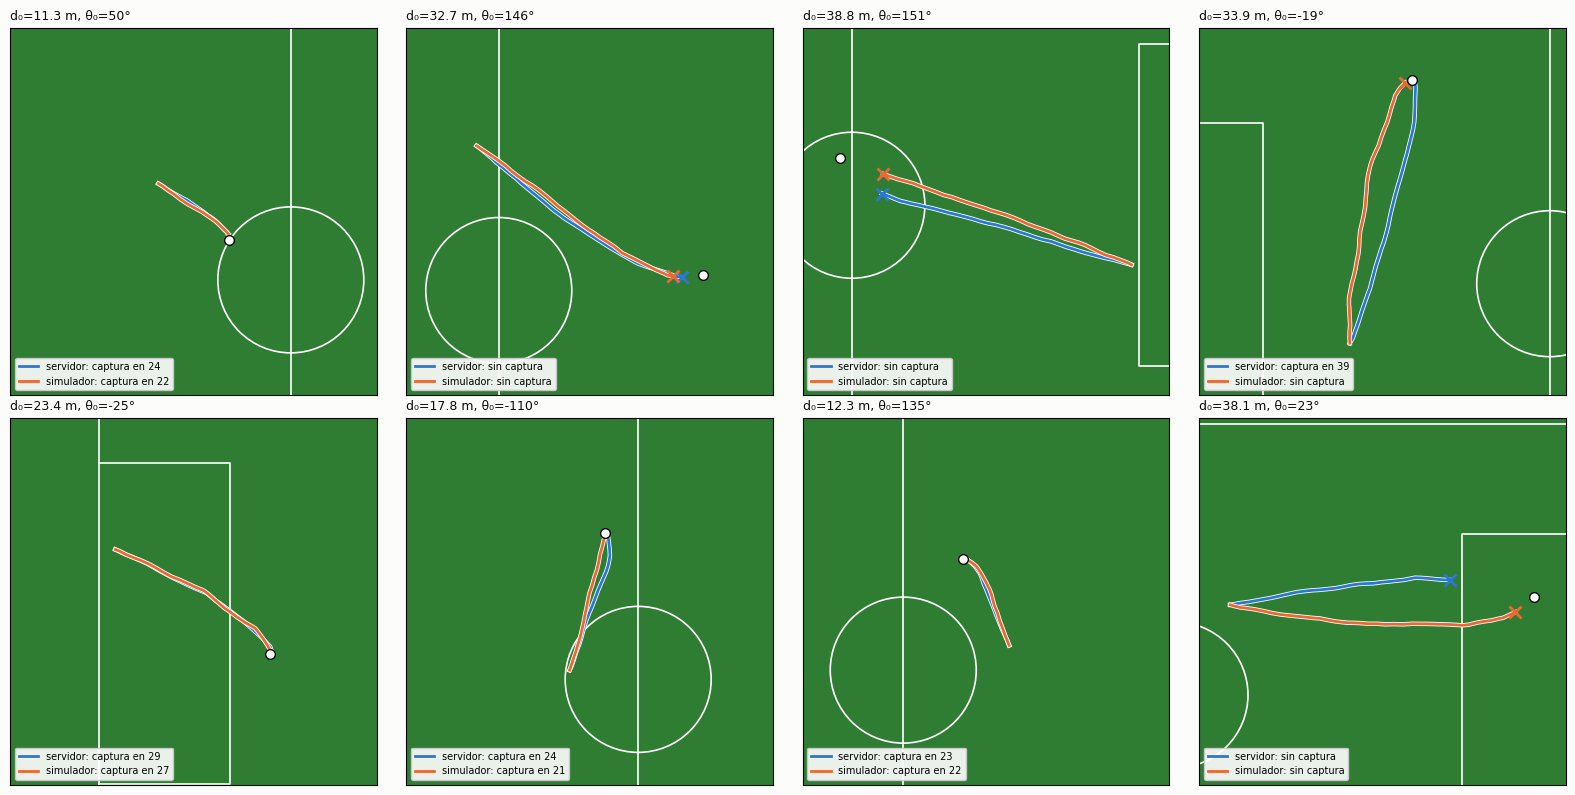

In [8]:
pairs = [(l, s) for l, s in zip(learned["live"], learned["sim"]) if "trajectory" in l and "trajectory" in s][:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for (l, s), ax in zip(pairs, axes.ravel()):
    plots.plot_trajectory_pair(l, s, ax=ax)
fig.tight_layout(); fig.savefig(f"{ART}/fig_live_vs_sim_trajectories.png", dpi=200)

## 6. Aprendizaje visto en el servidor

Las Q-tables guardadas durante el entrenamiento (tras 0, 500, …, 20 000 episodios; ver
`02_train_baseline.ipynb` §5) se ejecutan con su política greedy en `rcssserver`, sobre 4 inicios fijos (balón
delante, a la derecha, atrás-izquierda y atrás-derecha). Tonos claros = temprano, oscuros = tarde. Regenerar:
`python -m src.live_snapshots --run notebooks/artifacts/runs/qlearning_eps_decay_1.0_to_0.1/seed_4` (≈ 2 min).

| episodios de entrenamiento | capturas en servidor | pasos (servidor) | capturas en simulador | pasos (simulador) |
|---|---|---|---|---|
| 0 | 1/4 | [21, 40, 40, 40] | 0/4 | [40, 40, 40, 40] |
| 500 | 0/4 | [40, 40, 40, 40] | 0/4 | [40, 40, 40, 40] |
| 1000 | 1/4 | [23, 40, 40, 40] | 1/4 | [40, 40, 24, 40] |
| 2000 | 3/4 | [24, 23, 40, 31] | 3/4 | [24, 21, 21, 40] |
| 5000 | 4/4 | [22, 23, 21, 29] | 4/4 | [21, 21, 23, 29] |
| 10000 | 4/4 | [26, 18, 30, 28] | 4/4 | [24, 19, 27, 33] |
| 20000 | 4/4 | [24, 24, 23, 29] | 4/4 | [24, 24, 24, 31] |

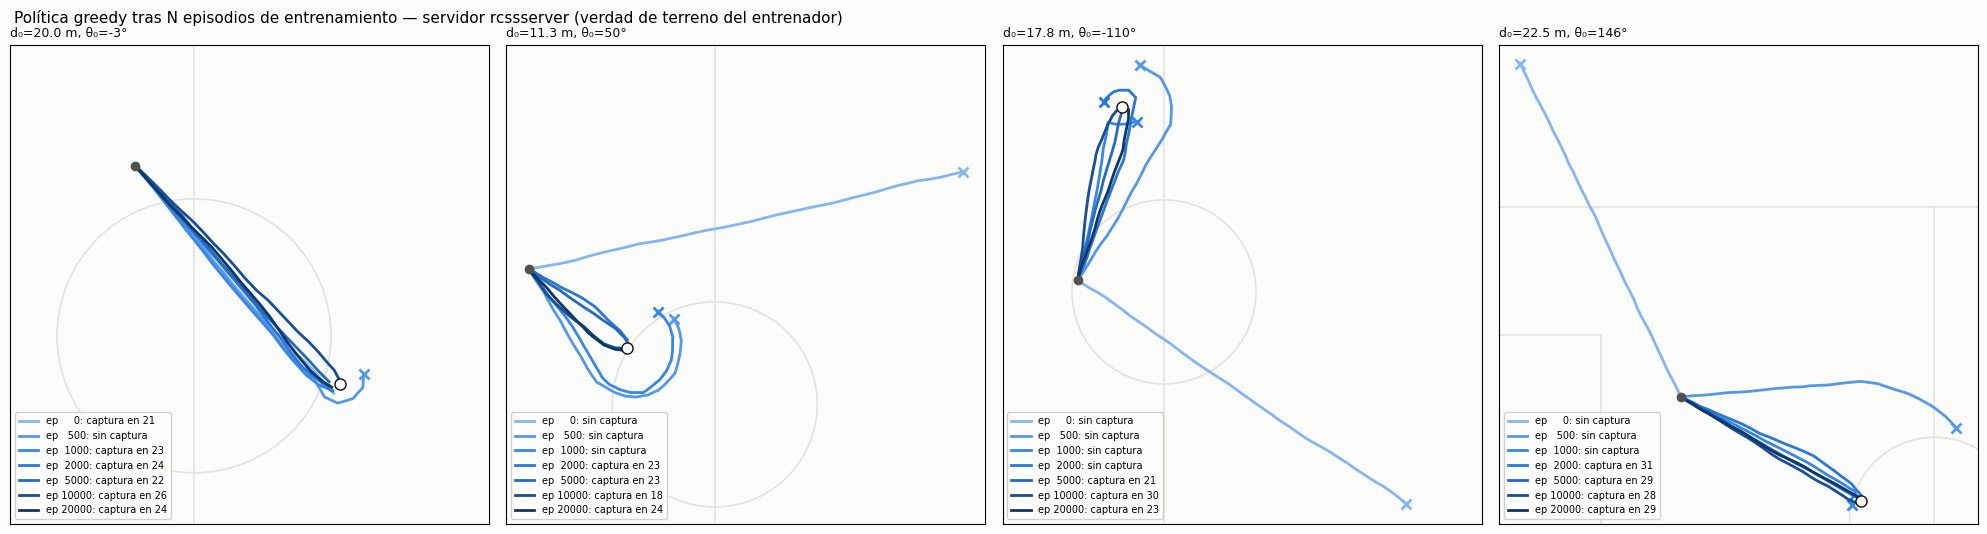

In [9]:
snaps = json.load(open(f"{ART}/live_snapshots.json"))["snapshots"]
keys = sorted(snaps, key=lambda k: int(k.split("_")[1]))
lines = ["| episodios de entrenamiento | capturas en servidor | pasos (servidor) | capturas en simulador | pasos (simulador) |",
         "|---|---|---|---|---|"]
for k in keys:
    lv, sm = snaps[k]["live"], snaps[k]["sim"]
    lines.append(f"| {int(k.split('_')[1])} | {sum(e['captured'] for e in lv)}/4 | {[e['steps'] for e in lv]} | "
                 f"{sum(e['captured'] for e in sm)}/4 | {[e['steps'] for e in sm]} |")
display(Markdown("\n".join(lines)))
fig, axes = plt.subplots(1, 4, figsize=(20, 5.4))
for j, ax in enumerate(axes):
    plots.plot_snapshot_trajectories(snaps, j, "live", ax=ax)
fig.suptitle("Política greedy tras N episodios de entrenamiento — servidor rcssserver (verdad de terreno del entrenador)",
             x=0.01, ha="left", fontsize=11)
fig.tight_layout(); fig.savefig(f"{ART}/fig_learning_trajectories_live.png", dpi=200)

In [10]:
p_live, se_live, n_live = rate(learned["live"], 39)
p_live40, _, _ = rate(learned["live"], 40)
display(Markdown(f"""### Resultado frente al criterio de la tarea

Política aprendida en el servidor: captura en < 40 pasos **{p_live:.1%}** (±{se_live:.1%}, n = {n_live});
en ≤ 40 pasos **{p_live40:.1%}**. Criterio de la tarea: > 90 %.

Con nuestra interpretación de un paso = un ciclo del servidor y nuestra distribución de inicios ($d_0$ uniforme
en [5, 40] m, rango del enunciado; la uniformidad es una decisión nuestra), el presupuesto de < 40 pasos es muy
restrictivo. Los fallos se concentran en los inicios lejanos (gráfico por distancia). Una estimación relajada
de girar y luego avanzar alcanza ≈ 89 %, lo que sugiere un problema de factibilidad, pero **no demuestra que
superar 90 % sea imposible**: la cota demostrable sin ruido es ≈ 95 % (`01_mdp_formulation.ipynb` §7), y el
controlador heurístico capturó un balón a 35.2 m en 39 pasos. Hace falta aclarar la duración de un paso y la
distribución de inicios prevista."""))

### Resultado frente al criterio de la tarea

Política aprendida en el servidor: captura en < 40 pasos **73.5%** (±3.1%, n = 200);
en ≤ 40 pasos **76.5%**. Criterio de la tarea: > 90 %.

Con nuestra interpretación de un paso = un ciclo del servidor y nuestra distribución de inicios ($d_0$ uniforme
en [5, 40] m, rango del enunciado; la uniformidad es una decisión nuestra), el presupuesto de < 40 pasos es muy
restrictivo. Los fallos se concentran en los inicios lejanos (gráfico por distancia). Una estimación relajada
de girar y luego avanzar alcanza ≈ 89 %, lo que sugiere un problema de factibilidad, pero **no demuestra que
superar 90 % sea imposible**: la cota demostrable sin ruido es ≈ 95 % (`01_mdp_formulation.ipynb` §7), y el
controlador heurístico capturó un balón a 35.2 m en 39 pasos. Hace falta aclarar la duración de un paso y la
distribución de inicios prevista.